In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim


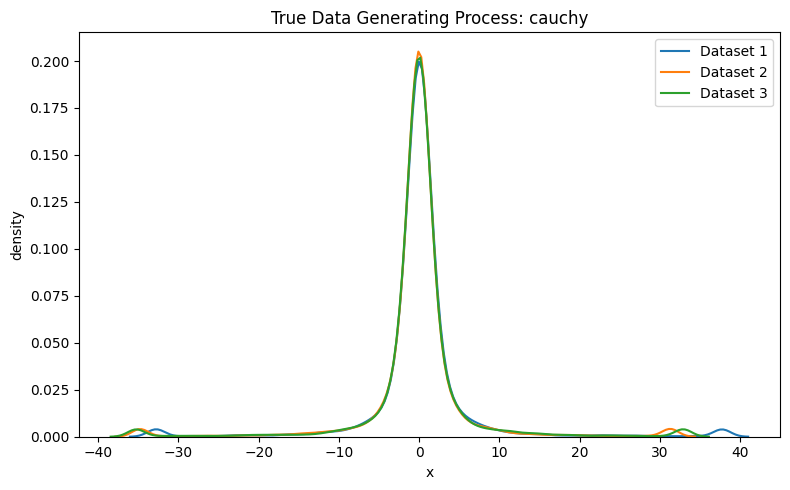

In [2]:
# --- Alternative true DGPs (data generators) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng # shorthand

def gen_gaussian(n=10000, mu=0.0, sigma=1.0, seed=None):
    r = rng(seed)
    return r.normal(mu, sigma, size=n)

def gen_student_t(n=10000, df=3, mu=0.0, sigma=1.0, seed=None):
    r = rng(seed)
    return mu + sigma * r.standard_t(df, size=n)

def gen_cauchy(n=10000, mu=0.0, sigma=1.0, seed=None):
    r = rng(seed)
    return mu + sigma * r.standard_cauchy(size=n)  # t with df=1

def gen_laplace(n=10000, mu=0.0, b=1.0, seed=None):
    r = rng(seed)
    return r.laplace(mu, b, size=n)  # heavier tails than Gaussian, no skew

def gen_log_normal(n=10000, m=0.0, s=1.0, seed=None):
    r = rng(seed)
    return r.lognormal(mean=m, sigma=s, size=n)  # right-skewed

def gen_contaminated_gaussian(n=10000, mu=0.0, sigma=1.0, eps=0.1, big_sigma=5.0, seed=None):
    r = rng(seed)
    x = r.normal(mu, sigma, size=n)
    mask = r.uniform(0, 1, size=n) < eps
    x[mask] = r.normal(mu, big_sigma, size=mask.sum())
    return x  # mixture with outliers

# Optional: a mild-scale standardizer just for *visualization* comparability (not required)
def clip_for_plot(x, q_lo=1, q_hi=99):
    lo, hi = np.percentile(x, [q_lo, q_hi])
    return np.clip(x, lo, hi)

# --- Choose your true DGP here ---
DGP_NAME = "cauchy"  # {"gaussian","student_t","cauchy","laplace","log_normal","contaminated_gaussian"}

def generate_datasets(dgp_name=DGP_NAME, n=10000, seed_offset=0):
    gens = {
        "gaussian": lambda s: gen_gaussian(n=n, mu=0.0, sigma=1.0, seed=None),
        "student_t": lambda s: gen_student_t(n=n, df=3, mu=0.0, sigma=1.0, seed=None),
        "cauchy": lambda s: gen_cauchy(n=n, mu=0.0, sigma=1.0, seed=None),
        "laplace": lambda s: gen_laplace(n=n, mu=0.0, b=1.0, seed=None),
        "log_normal": lambda s: gen_log_normal(n=n, m=0.0, s=1.0, seed=None),
        "contaminated_gaussian": lambda s: gen_contaminated_gaussian(n=n, mu=0.0, sigma=1.0, eps=0.1, big_sigma=5.0, seed=None),
    }
    if dgp_name not in gens:
        raise ValueError(f"Unknown DGP '{dgp_name}'")
    return [gens[dgp_name](seed_offset + i) for i in range(3)]

# --- Generate 3 independent datasets from the chosen true DGP ---
datasets = generate_datasets(DGP_NAME, n=10000, seed_offset=0)

# --- Visualize (clip only for plotting so KDEs are readable) ---
plt.figure(figsize=(8,5))
for i, data in enumerate(datasets, 1):
    sns.kdeplot(clip_for_plot(data), label=f"Dataset {i}")
plt.title(f"True Data Generating Process: {DGP_NAME}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()



In [3]:
import numpy as np
import math

# --- DGP configuration you are using right now (must match your generator) ---
# Pick one of: "gaussian","student_t","cauchy","laplace","log_normal","contaminated_gaussian"
DGP_NAME = "cauchy"  # reuse your existing variable
DGP_PARAMS = {
    "gaussian":               {"mu": 0.0, "sigma": 1.0},
    "student_t":              {"mu": 0.0, "sigma": 1.0, "df": 3},
    "cauchy":                 {"mu": 0.0, "sigma": 1.0},              # t with df = 1
    "laplace":                {"mu": 0.0, "b": 1.0},
    "log_normal":             {"m": 0.0, "s": 1.0},                   # log X ~ N(m, s^2)
    "contaminated_gaussian":  {"mu": 0.0, "sigma": 1.0, "eps": 0.1, "big_sigma": 5.0},
}

def _normal_pdf(x, mu, sigma):
    return (1.0/(math.sqrt(2*math.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

def _student_t_pdf(x, mu, sigma, df):
    # If T ~ t_df, X = mu + sigma*T ⇒ f_X(x) = t_pdf((x-mu)/sigma)/sigma
    z = (x - mu) / sigma
    c = math.gamma((df+1)/2) / (math.sqrt(df*math.pi) * math.gamma(df/2))
    return (c * (1 + (z**2)/df) ** (-(df+1)/2)) / sigma

def _cauchy_pdf(x, mu, sigma):
    # Cauchy is t with df=1
    return _student_t_pdf(x, mu, sigma, df=1)

def _laplace_pdf(x, mu, b):
    return (1.0/(2.0*b)) * np.exp(-np.abs(x-mu)/b)

def _lognormal_pdf(x, m, s):
    out = np.zeros_like(x, dtype=float)
    pos = x > 0
    out[pos] = (1.0/(x[pos]*s*math.sqrt(2*math.pi))) * np.exp(-(np.log(x[pos]) - m)**2 / (2*s*s))
    return out

def _mixture_pdf(x, weights, pdfs):
    # weights: list of scalars summing to 1; pdfs: list of arrays (same shape as x)
    mix = np.zeros_like(x, dtype=float)
    for w, p in zip(weights, pdfs):
        mix += w * p
    return mix

def true_predictive_pdf(x_grid, dgp_name, params):
    x_grid = np.asarray(x_grid, dtype=float)
    if dgp_name == "gaussian":
        return _normal_pdf(x_grid, params["mu"], params["sigma"])
    elif dgp_name == "student_t":
        return _student_t_pdf(x_grid, params["mu"], params["sigma"], params["df"])
    elif dgp_name == "cauchy":
        return _cauchy_pdf(x_grid, params["mu"], params["sigma"])
    elif dgp_name == "laplace":
        return _laplace_pdf(x_grid, params["mu"], params["b"])
    elif dgp_name == "log_normal":
        return _lognormal_pdf(x_grid, params["m"], params["s"])
    elif dgp_name == "contaminated_gaussian":
        mu, sig, eps, big = params["mu"], params["sigma"], params["eps"], params["big_sigma"]
        base = _normal_pdf(x_grid, mu, sig)
        outl = _normal_pdf(x_grid, mu, big)
        return _mixture_pdf(x_grid, [1.0-eps, eps], [base, outl])
    else:
        raise ValueError(f"Unknown DGP '{dgp_name}'")


In [4]:


_TWO_PI = 2.0 * math.pi

def _int_power_normal(var: torch.Tensor, beta: float):
    """
    ∫ N(y; m, var)^β dy = (2π var)^{(1-β)/2} * β^{-1/2}.
    (independent of mean)
    """
    var = torch.clamp(var, min=1e-12)
    return (_TWO_PI * var)**((1.0 - beta) / 2.0) * (beta ** (-0.5))

def _cross_int_q_fbeta1(m_q, v_q, m_p, v_p, beta: float):
    """
    ∫ q(y) * f(y)^{β-1} dy for q=N(m_q,v_q), f=N(m_p,v_p).
    """
    v_q = torch.clamp(v_q, min=1e-12)
    v_p = torch.clamp(v_p, min=1e-12)
    a = 1.0 / v_q
    b = (beta - 1.0) / v_p
    denom = a + b
    # prefactors: (2π v_q)^{-1/2} (2π v_p)^{-(β-1)/2}
    pref = (_TWO_PI * v_q)**(-0.5) * (_TWO_PI * v_p)**(-(beta - 1.0) / 2.0)
    # Gaussian integral:
    expo = -0.5 * (a * m_q**2 + b * m_p**2 - (a * m_q + b * m_p)**2 / denom)
    integ = pref * torch.sqrt(2.0 * math.pi / denom) * torch.exp(expo)
    return integ

def beta_divergence_normal(m_q, v_q, m_p, v_p, beta: float):
    """
    D_β between two univariate Gaussians q and π.
    """
    if beta <= 0.0:
        raise ValueError("beta must be > 0.")
    if abs(beta - 1.0) < 1e-4:
        # fall back to KL for numerical stability near β=1
        # KL(q||p) for univariate normals
        v_q = torch.clamp(v_q, min=1e-12)
        v_p = torch.clamp(v_p, min=1e-12)
        return 0.5 * ( (v_q / v_p) + (m_q - m_p)**2 / v_p - 1.0 + torch.log(v_p / v_q) )

    I_q = _int_power_normal(v_q, beta)     # ∫ q^β
    I_p = _int_power_normal(v_p, beta)     # ∫ π^β
    I_qp = _cross_int_q_fbeta1(m_q, v_q, m_p, v_p, beta)  # ∫ q π^{β-1}

    b = torch.tensor(beta, dtype=m_q.dtype, device=m_q.device)
    term1 = I_q / (b * (b - 1.0))
    term2 = I_p / b
    term3 = I_qp / (b - 1.0)
    return term1 + term2 - term3


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------
# CONFIG
# ------------------------------
BATCH_SIZE = 32           # minibatch size
MC_SAMPLES = 100          # samples from q per step
STEPS      = 2000         # training iterations
LR         = 1e-2         # learning rate
SEED       = 123          # set an int for deterministic runs

# ------------------------------
# SEED HANDLING (deterministic)
# ------------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Running deterministically with SEED={SEED}")

# ------------------------------
# VARIATIONAL FAMILY
# ------------------------------
class VariationalGaussian(nn.Module):
    def __init__(self, init_m=0.0, init_log_s=-2.0,
                 init_m_log_sigma2=0.0, init_log_s_log_sigma2=-2.0):
        super().__init__()
        # variational params for mu
        self.m_mu      = nn.Parameter(torch.tensor(float(init_m)))
        self.log_s_mu  = nn.Parameter(torch.tensor(float(init_log_s)))

        # variational params for log sigma^2
        self.m_logsig      = nn.Parameter(torch.tensor(float(init_m_log_sigma2)))
        self.log_s_logsig  = nn.Parameter(torch.tensor(float(init_log_s_log_sigma2)))

    def sample_mu(self, num_samples=1):
        eps = torch.randn(num_samples, device=self.m_mu.device)
        return self.m_mu + torch.exp(self.log_s_mu) * eps

    def sample_sigma2(self, num_samples=1):
        eps = torch.randn(num_samples, device=self.m_logsig.device)
        log_sigma2 = self.m_logsig + torch.exp(self.log_s_logsig) * eps
        return torch.exp(log_sigma2)  # ensures positivity

    def kl_divergence_mu(self, prior_mean=0.0, prior_std=1.001):
        """KL between q(mu) and N(prior_mean, prior_std^2)."""
        q_var = torch.exp(self.log_s_mu)**2
        tau2  = prior_std**2
        kl = 0.5 * ((q_var + (self.m_mu - prior_mean)**2)/tau2 
                    - 1.0 - torch.log(q_var/tau2 + 1e-12))
        return kl

    def kl_divergence_sigma2(self, prior_mean=0.0, prior_std=1.001):
        """KL between q(log sigma^2) and N(prior_mean, prior_std^2)."""
        q_var = torch.exp(self.log_s_logsig)**2
        tau2  = prior_std**2
        kl = 0.5 * ((q_var + (self.m_logsig - prior_mean)**2)/tau2 
                    - 1.0 - torch.log(q_var/tau2 + 1e-12))
        return kl

    def beta_divergence_to_prior(self,
                                 mu_prior_mean=0.0,  mu_prior_std=5.0,
                                 logsig_prior_mean=0.0, logsig_prior_std=3.0,
                                 beta=0.5):
        """
        D_β(q(μ)||π(μ)) + D_β(q(log σ²)||π(log σ²))
        using independent Normal priors on μ and log σ².
        """
        # for μ
        vq_mu = torch.exp(self.log_s_mu)**2
        vp_mu = torch.tensor(mu_prior_std**2, dtype=vq_mu.dtype, device=vq_mu.device)
        mq_mu = self.m_mu
        mp_mu = torch.tensor(mu_prior_mean, dtype=mq_mu.dtype, device=mq_mu.device)

        # for log σ²
        vq_ls = torch.exp(self.log_s_logsig)**2
        vp_ls = torch.tensor(logsig_prior_std**2, dtype=vq_ls.dtype, device=vq_ls.device)
        mq_ls = self.m_logsig
        mp_ls = torch.tensor(logsig_prior_mean, dtype=mq_ls.dtype, device=mq_ls.device)

        d_mu = beta_divergence_normal(mq_mu, vq_mu, mp_mu, vp_mu, beta)
        d_ls = beta_divergence_normal(mq_ls, vq_ls, mp_ls, vp_ls, beta)
        return d_mu + d_ls



Running deterministically with SEED=123


In [6]:
def kld_loss_norm(y, mu, sigma2):
    return -torch.distributions.Normal(mu, sigma2.sqrt()).log_prob(y).sum()

def beta_loss_norm(y, mu, sigma2, beta):
    """
    β-loss (as implemented in Jewson's repo)
    """
    log_px = -0.5 * (y - mu)**2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)
    px_beta = torch.exp(beta * log_px)

    likelihood_term = (1.0 / beta) * px_beta
    integral = 1.0 / ((2 * torch.pi)**(beta/2.0) * (1.0 + beta)**1.5 * (sigma2**(beta/2.0)))

    return -(likelihood_term.sum() - y.numel() * integral)


def gamma_loss_norm(y, mu, sigma2, gamma):
    """
    γ-loss (Jewson et al.) without σ²_adj
    """
    log_px   = -0.5 * (y - mu)**2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)
    px_gamma = torch.exp(gamma * log_px)

    integral = 1.0 / ((2 * torch.pi)**(gamma/2.0) * ((1.0 + gamma)**0.5) * (sigma2**(gamma/2.0)))
    like_sum = (1.0 / gamma) * px_gamma.sum() * (1.0 / (gamma + 1.0)) * (integral ** (-gamma/(gamma + 1.0)))

    return -(like_sum - y.numel() * integral)



In [7]:
def divergence_kl(q: VariationalGaussian,
                  prior_mean_mu=0.0, prior_std_mu=5.0,
                  prior_mean_logsig=0.0, prior_std_logsig=3.0):
    return (
        q.kl_divergence_mu(prior_mean=prior_mean_mu, prior_std=prior_std_mu) +
        q.kl_divergence_sigma2(prior_mean=prior_mean_logsig, prior_std=prior_std_logsig)
    )

def divergence_beta(q: VariationalGaussian, beta=0.5,
                    prior_mean_mu=0.0, prior_std_mu=5.0,
                    prior_mean_logsig=0.0, prior_std_logsig=3.0):
    return q.beta_divergence_to_prior(
        mu_prior_mean=prior_mean_mu, mu_prior_std=prior_std_mu,
        logsig_prior_mean=prior_mean_logsig, logsig_prior_std=prior_std_logsig,
        beta=beta
    )

def divergence_gamma(q: VariationalGaussian, gamma=0.5,
                     prior_mean_mu=0.0, prior_std_mu=5.0,
                     prior_mean_logsig=0.0, prior_std_logsig=3.0):
    return q.gamma_divergence_to_prior(
        mu_prior_mean=prior_mean_mu, mu_prior_std=prior_std_mu,
        logsig_prior_mean=prior_mean_logsig, logsig_prior_std=prior_std_logsig,
        gamma=gamma
    )


In [8]:
from math import ceil
from torch.utils.data import DataLoader, TensorDataset

def make_minibatches(x_numpy, batch_size=BATCH_SIZE, shuffle=True):
    x = torch.tensor(x_numpy, dtype=torch.float32)
    ds = TensorDataset(x)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


In [9]:
def train_gvi(
    x_numpy,
    loss_type="beta",        
    divergence_type="kl",  
    beta=0.5,
    gamma=0.5,
    steps=100,
    lr=0.001,
    batch_size=64,
    mc_samples=10,
    # If None, we will set these from training data automatically
    init_m=None,
    init_log_s=-2.0,
    init_m_log_sigma2=None,
    init_log_s_log_sigma2=-2.0,
    prior_mean_mu=None,
    prior_std_mu=None,
    prior_mean_logsig=None,
    prior_std_logsig=None,
):
    # ------------------------------------
    # Set priors & init from training data
    # ------------------------------------
    train_mean = float(np.mean(x_numpy))
    train_std  = float(np.std(x_numpy, ddof=1))
    train_var  = train_std**2

    # initialization of variational params
    if init_m is None:
        init_m = train_mean
    if init_m_log_sigma2 is None:
        init_m_log_sigma2 = np.log(train_var)

    # priors
    if prior_mean_mu is None:
        prior_mean_mu = train_mean
    if prior_std_mu is None:
        prior_std_mu = 2.0 * train_std
    if prior_mean_logsig is None:
        prior_mean_logsig = np.log(train_var)
    if prior_std_logsig is None:
        prior_std_logsig = 1.5

    # ------------------------------------
    # Build DataLoader
    # ------------------------------------
    loader = make_minibatches(x_numpy, batch_size=batch_size, shuffle=True)
    N = len(x_numpy)

    # variational family
    q   = VariationalGaussian(init_m, init_log_s,
                              init_m_log_sigma2, init_log_s_log_sigma2)
    opt = optim.Adam(q.parameters(), lr=lr)

    # choose data loss
    if loss_type == "nll":
        def loss_fn(mu, xb, sigma2):
            return kld_loss_norm(xb, mu, sigma2)
    elif loss_type == "beta":
        def loss_fn(mu, xb, sigma2):
            return beta_loss_norm(xb, mu, sigma2, beta)
    elif loss_type == "gamma":
        def loss_fn(mu, xb, sigma2):
            return gamma_loss_norm(xb, mu, sigma2, gamma)
    else:
        raise ValueError("loss_type must be one of {'nll','beta','gamma'}")

    # ------------------------------------
    # Training loop
    # ------------------------------------
    step = 0
    while step < steps:
        for (xb,) in loader:
            opt.zero_grad()

            # Monte Carlo over q(μ, σ²)
            K = xb.shape[0]
            mc_vals = []
            for _ in range(mc_samples):
                mu_s     = q.sample_mu(1).squeeze(0)
                sigma2_s = q.sample_sigma2(1).squeeze(0)
                ell_sum_batch = loss_fn(mu_s, xb, sigma2_s)
                ell_full      = (N / K) * ell_sum_batch
                mc_vals.append(ell_full)

            data_term = torch.stack(mc_vals).mean()

            # prior regularization
            if divergence_type == "kl":
                reg_term = (
                    q.kl_divergence_mu(prior_mean=prior_mean_mu,
                                       prior_std=prior_std_mu)
                    + q.kl_divergence_sigma2(prior_mean=prior_mean_logsig,
                                             prior_std=prior_std_logsig)
                )
            elif divergence_type == "beta":
                reg_term = q.beta_divergence_to_prior(
                    mu_prior_mean=prior_mean_mu,  mu_prior_std=prior_std_mu,
                    logsig_prior_mean=prior_mean_logsig, logsig_prior_std=prior_std_logsig,
                    beta=beta
                )
            else:
                raise ValueError("divergence_type must be {'kl','beta'}")

            # final objective
            obj = data_term + reg_term
            obj.backward()
            opt.step()

            step += 1
            if step >= steps:
                break

    return q




In [10]:
def posterior_predictive(q: VariationalGaussian, grid, num_samples=500):
    """
    p(x*|data) ≈ (1/S) Σ N(x* | μ^(s), σ²^(s))
    """
    with torch.no_grad():
        mus     = q.sample_mu(num_samples=num_samples).cpu().numpy()
        sigma2s = q.sample_sigma2(num_samples=num_samples).cpu().numpy()

    grid = np.asarray(grid)
    preds = np.zeros_like(grid, dtype=float)
    for mu, sigma2 in zip(mus, sigma2s):
        coef = 1.0 / np.sqrt(2 * np.pi * sigma2)
        preds += coef * np.exp(-0.5 * ((grid - mu)**2) / sigma2)

    return preds / num_samples


In [11]:
grid = np.linspace(-6, 6, 400)

methods = [
    ("nll",   {"beta": None, "gamma": None}),
    ("beta",  {"beta": 1.2, "gamma": None}),
    ("gamma", {"beta": None, "gamma": 0.9}),
]

true_curve = true_predictive_pdf(grid, DGP_NAME, DGP_PARAMS[DGP_NAME])

for method, params in methods:
    plt.figure(figsize=(8,5))
    for j, data_j in enumerate(datasets, 1):
        if method == "nll":
            qj = train_gvi(
                data_j, loss_type="nll", divergence_type="kl",
                steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES
            )
        elif method == "beta":
            qj = train_gvi(
                data_j, loss_type="beta", divergence_type="beta",
                beta=params["beta"], steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES
            )
        elif method == "gamma":
            qj = train_gvi(
                data_j, loss_type="gamma", divergence_type="kl",
                gamma=params["gamma"], steps=STEPS, lr=LR, batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES
            )
        else:
            raise RuntimeError("unreachable")

        pred_j = posterior_predictive(qj, grid, num_samples=500)
        plt.plot(grid, pred_j, label=f"Dataset {j}")

    plt.plot(grid, true_curve, "k--", linewidth=2.0, label="True DGP")
    ttl = f"Posterior Predictive (loss = {method.upper()}, divergence = KL) + True DGP"
    plt.title(ttl)
    plt.xlabel("x*")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()


NameError: name 'train_gvi_ar1' is not defined